In [ ]:
#Hamza ALsihati
#2230006810
#8MA1
import cv2
import numpy as np
import matplotlib.pyplot as plt

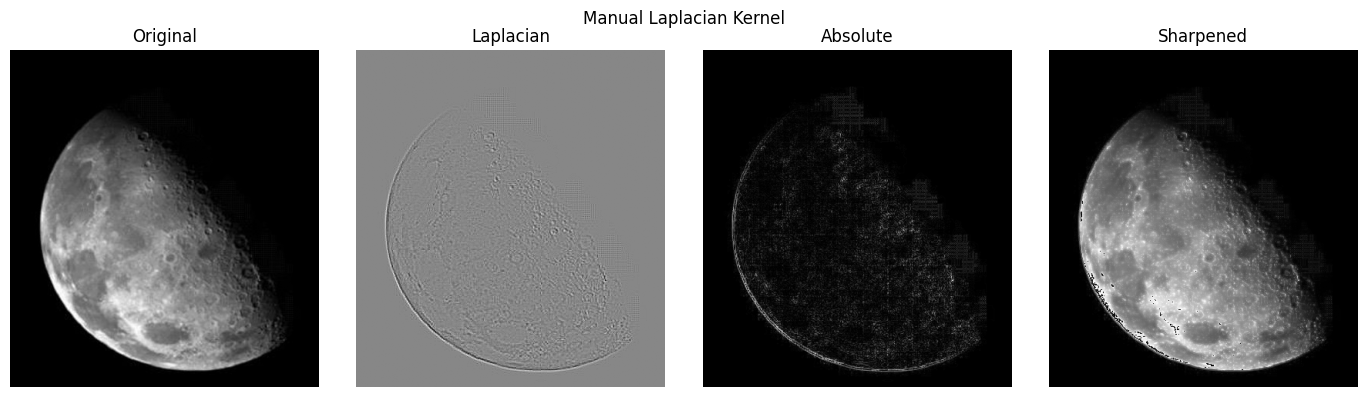

In [21]:
img = cv2.imread('Images/moon.jpg', 0)

kernel = np.array([[0,  1,  0], [1, -4,  1], [0,  1,  0]], dtype=np.float32)
laplacian = cv2.filter2D(img, cv2.CV_64F, kernel)
laplacian_abs = cv2.convertScaleAbs(laplacian)
sharpened = img + laplacian_abs

plt.figure(figsize=(14, 4))
plt.subplot(141)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(142)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.axis('off')
plt.subplot(143)
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Absolute')
plt.axis('off')
plt.subplot(144)
plt.imshow(sharpened, cmap='gray')
plt.title('Sharpened')
plt.axis('off')
plt.suptitle('Manual Laplacian Kernel')
plt.tight_layout()
plt.show()

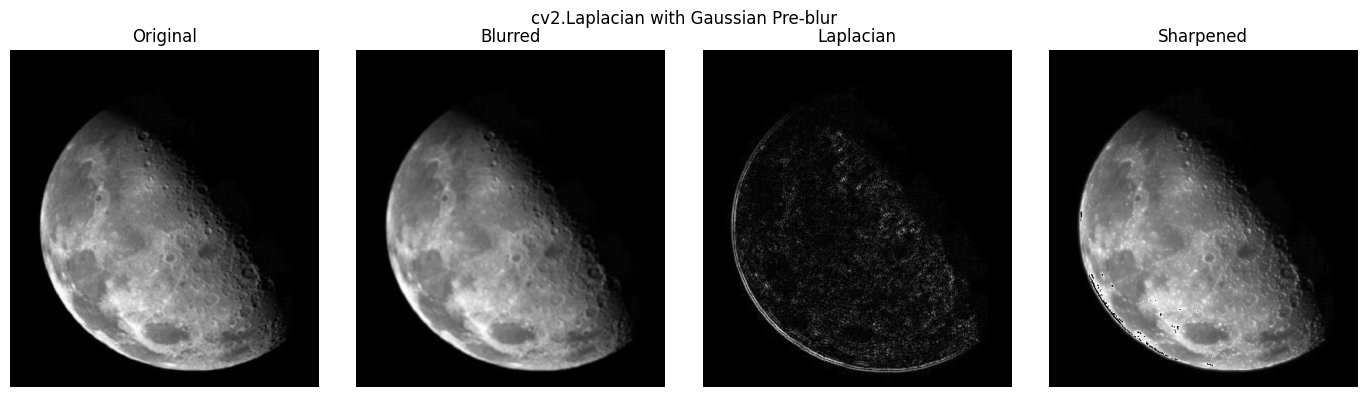

In [22]:
blurred = cv2.GaussianBlur(img, (3, 3), 0)
lap = cv2.Laplacian(blurred, cv2.CV_64F)
lap_abs = cv2.convertScaleAbs(lap)
sharpened2 = img + lap_abs

plt.figure(figsize=(14, 4))
plt.subplot(141)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(142)
plt.imshow(blurred, cmap='gray')
plt.title('Blurred')
plt.axis('off')
plt.subplot(143)
plt.imshow(lap_abs, cmap='gray')
plt.title('Laplacian')
plt.axis('off')
plt.subplot(144)
plt.imshow(sharpened2, cmap='gray')
plt.title('Sharpened')
plt.axis('off')
plt.suptitle('cv2.Laplacian with Gaussian Pre-blur')
plt.tight_layout()
plt.show()

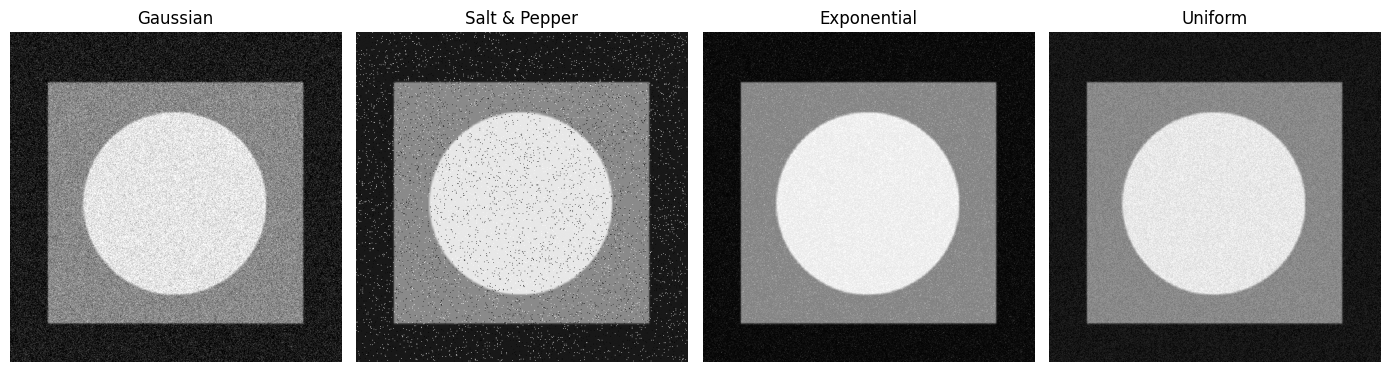

In [23]:
img = cv2.imread('Images/noise.jpg', 0)

def add_noise(image, noise_type):
    row, col = image.shape
    if noise_type == 'gaussian':
        gauss = np.random.normal(0, 0.1, (row, col))
        noisy = image / 255 + gauss
        return np.clip(noisy * 255, 0, 255).astype(np.uint8)
    
    elif noise_type == 'salt_pepper':
        noisy = np.copy(image)
        n = int(0.02 * image.size)
        salt_coords   = [np.random.randint(0, i - 1, n) for i in image.shape]
        pepper_coords = [np.random.randint(0, i - 1, n) for i in image.shape]
        noisy[tuple(salt_coords)]   = 255
        noisy[tuple(pepper_coords)] = 0
        return noisy
    
    elif noise_type == 'exponential':
        expo = np.random.exponential(10.0, (row, col))
        return np.clip(image + expo, 0, 255).astype(np.uint8)
    
    elif noise_type == 'uniform':
        uni = np.random.uniform(-20, 20, (row, col))
        return np.clip(image + uni, 0, 255).astype(np.uint8)

noise_gauss = add_noise(img, 'gaussian')
noise_sp = add_noise(img, 'salt_pepper')
noise_expo = add_noise(img, 'exponential')
noise_uni = add_noise(img, 'uniform')

plt.figure(figsize=(14, 4))
plt.subplot(141)
plt.imshow(noise_gauss, cmap='gray')
plt.title('Gaussian')
plt.axis('off')
plt.subplot(142)
plt.imshow(noise_sp, cmap='gray')
plt.title('Salt & Pepper')
plt.axis('off')
plt.subplot(143)
plt.imshow(noise_expo, cmap='gray')
plt.title('Exponential')
plt.axis('off')
plt.subplot(144)
plt.imshow(noise_uni, cmap='gray')
plt.title('Uniform')
plt.axis('off')
plt.tight_layout()
plt.show()

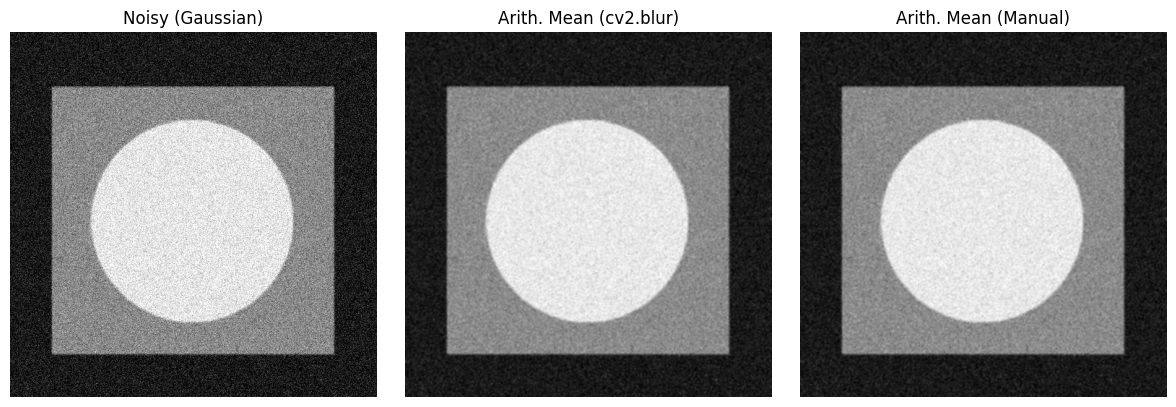

In [24]:
arith_builtin = cv2.blur(noise_gauss, (3, 3))
kernel = np.ones((3, 3), np.float32) / 9
arith_manual = cv2.filter2D(noise_gauss, -1, kernel)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(noise_gauss, cmap='gray')
plt.title('Noisy (Gaussian)')
plt.axis('off')
plt.subplot(132)
plt.imshow(arith_builtin, cmap='gray')
plt.title('Arith. Mean (cv2.blur)')
plt.axis('off')
plt.subplot(133)
plt.imshow(arith_manual, cmap='gray')
plt.title('Arith. Mean (Manual)')
plt.axis('off')
plt.tight_layout()
plt.show()

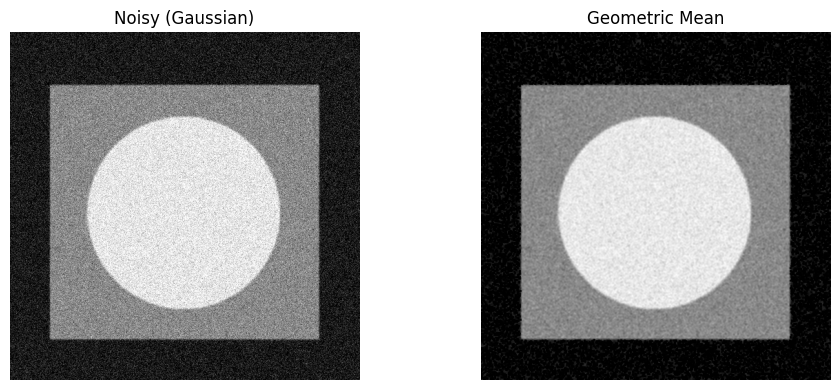

In [25]:
def geometric_mean_filter(image, k=3):
    img_f    = image.astype(np.float64) + 1e-6
    kernel   = np.ones((k, k), np.float32) / (k * k)
    mean_log = cv2.filter2D(np.log(img_f), -1, kernel)
    return np.clip(np.exp(mean_log), 0, 255).astype(np.uint8)

geometric = geometric_mean_filter(noise_gauss)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(noise_gauss, cmap='gray')
plt.title('Noisy (Gaussian)')
plt.axis('off')
plt.subplot(122)
plt.imshow(geometric, cmap='gray')
plt.title('Geometric Mean')
plt.axis('off')
plt.tight_layout()
plt.show()

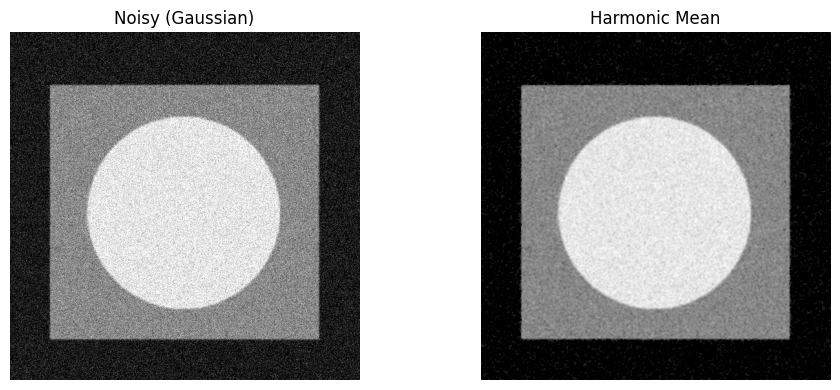

In [26]:
def harmonic_mean_filter(image, k=3):
    img_f = image.astype(np.float64) + 1e-6
    kernel = np.ones((k, k), np.float32)
    sum_recip = cv2.filter2D(1.0 / img_f, -1, kernel)
    return np.clip((k * k) / sum_recip, 0, 255).astype(np.uint8)

harm = harmonic_mean_filter(noise_gauss)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(noise_gauss, cmap='gray')
plt.title('Noisy (Gaussian)')
plt.axis('off')
plt.subplot(122)
plt.imshow(harm, cmap='gray')
plt.title('Harmonic Mean')
plt.axis('off')
plt.tight_layout()
plt.show()

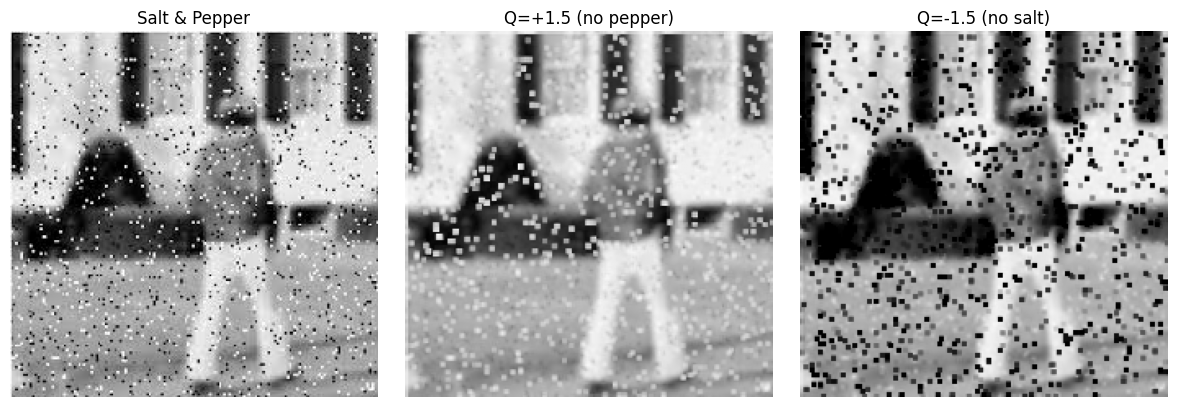

In [27]:
def contra_harmonic_mean(image, k=3, Q=0):
    img_f = image.astype(np.float64) + 1e-6
    kernel = np.ones((k, k), np.float32)
    num = cv2.filter2D(np.power(img_f, Q + 1), -1, kernel)
    den = cv2.filter2D(np.power(img_f, Q), -1, kernel)
    return np.clip(num / (den + 1e-6), 0, 255).astype(np.uint8)

sp_img = cv2.imread('Images/salt&Pepper.jpg', 0)
pepper_removed = contra_harmonic_mean(sp_img, Q= 1.5)
salt_removed = contra_harmonic_mean(sp_img, Q=-1.5)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(sp_img, cmap='gray')
plt.title('Salt & Pepper')
plt.axis('off')
plt.subplot(132)
plt.imshow(pepper_removed, cmap='gray')
plt.title('Q=+1.5 (no pepper)')
plt.axis('off')
plt.subplot(133)
plt.imshow(salt_removed, cmap='gray')
plt.title('Q=-1.5 (no salt)')
plt.axis('off')
plt.tight_layout()
plt.show()

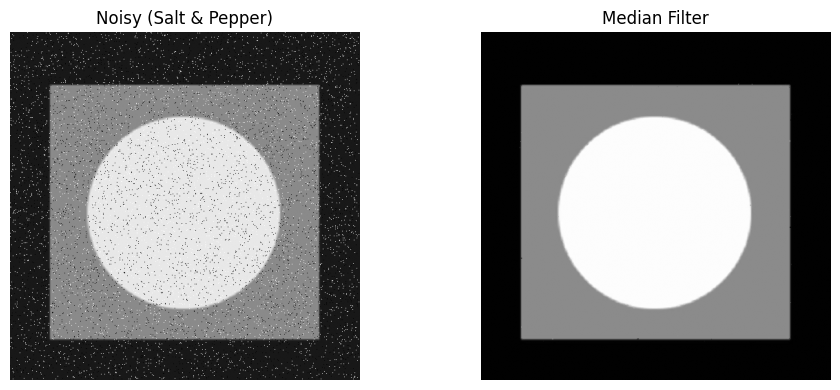

In [28]:
median_result = cv2.medianBlur(noise_sp, 3)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(noise_sp, cmap='gray')
plt.title('Noisy (Salt & Pepper)')
plt.axis('off')
plt.subplot(122)
plt.imshow(median_result, cmap='gray')
plt.title('Median Filter'),plt.axis('off')
plt.tight_layout()
plt.show()

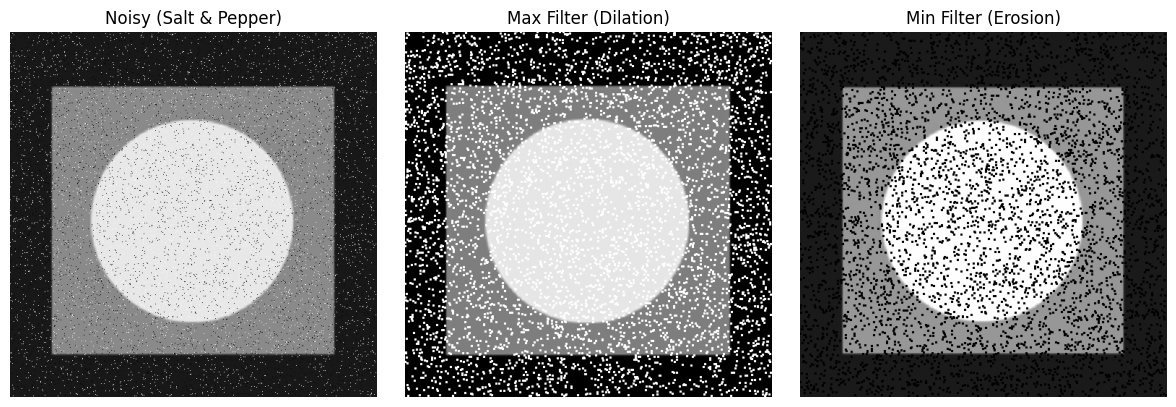

In [29]:
kernel = np.ones((3, 3), np.uint8)
max_filter = cv2.dilate(noise_sp, kernel)
min_filter = cv2.erode(noise_sp,  kernel)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(noise_sp, cmap='gray')
plt.title('Noisy (Salt & Pepper)')
plt.axis('off')
plt.subplot(132)
plt.imshow(max_filter, cmap='gray')
plt.title('Max Filter (Dilation)')
plt.axis('off')
plt.subplot(133)
plt.imshow(min_filter, cmap='gray')
plt.title('Min Filter (Erosion)')
plt.axis('off')
plt.tight_layout()
plt.show()

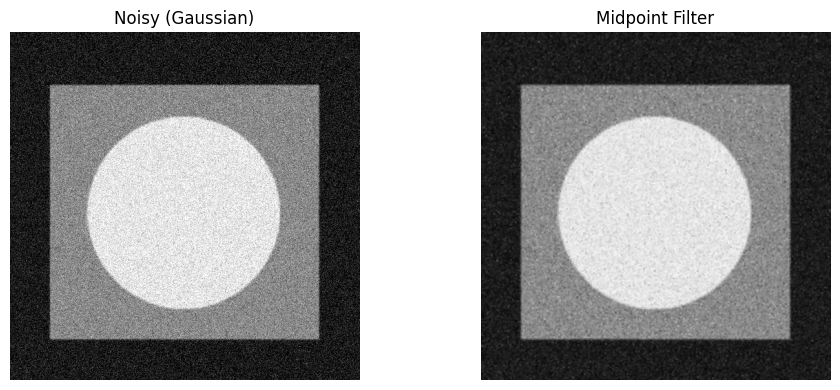

In [30]:
def midpoint_filter(image, k=3):
    kernel  = np.ones((k, k), np.uint8)
    max_img = cv2.dilate(image, kernel).astype(np.float64)
    min_img = cv2.erode(image,  kernel).astype(np.float64)
    return ((max_img + min_img) / 2).astype(np.uint8)

mid_result = midpoint_filter(noise_gauss)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(noise_gauss, cmap='gray')
plt.title('Noisy (Gaussian)')
plt.axis('off')
plt.subplot(122)
plt.imshow(mid_result, cmap='gray')
plt.title('Midpoint Filter')
plt.axis('off')
plt.tight_layout()
plt.show()